## Today's topics

- Central Limit Theorem
- Chi-Square Test
- Test Implementation of categorical data

---


# 🔹 Part 1: Central Limit Theorem (CLT)

The Central Limit Theorem states:

> The sampling distribution of the sample mean becomes approximately normal
> as sample size increases (n ≥ 30), regardless of population distribution.


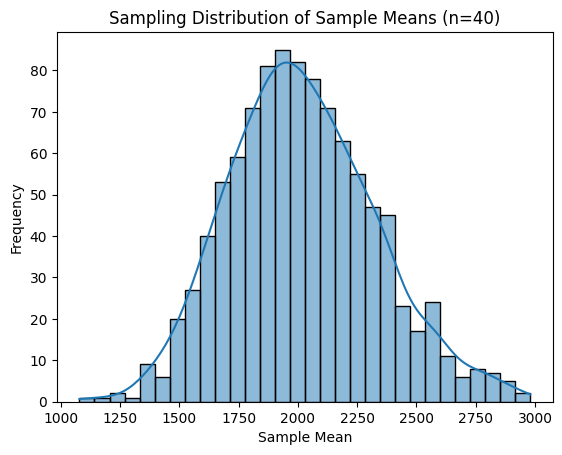

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

population = np.random.exponential(scale=2000, size=100000)

sample_means = []

for _ in range(1000):
    sample = np.random.choice(population, size=40)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)

sns.histplot(sample_means, bins=30, kde=True)
plt.title("Sampling Distribution of Sample Means (n=40)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()



# 🔹 Part 2: Chi-Square Test (Goodness of Fit)

Example:

A company claims that customer preference for 4 flavors is equally distributed.

Observed survey results:

| Flavor | Observed |
| -------|----------|
|   A    |    30    |
|   B    |    25    |
|   C    |    20    |
|   D    |    25    |

We test whether preferences are truly equal.

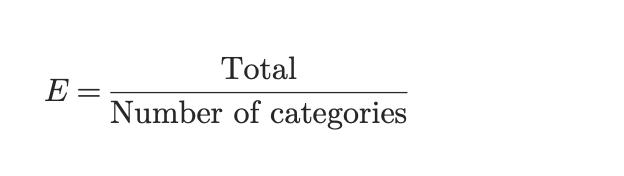

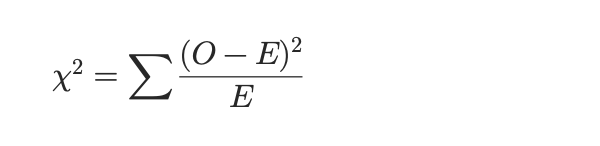

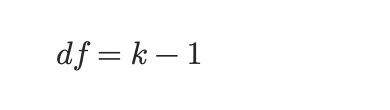

In [ ]:
# Chi-Square Test (Goodness of Fit)

import numpy as np
from scipy import stats

# -----------------------------
# Step 1: Observed Frequencies
# -----------------------------
observed = np.array([30, 25, 20, 25])

# -----------------------------
# Step 2: Expected Frequencies
# (Equal distribution assumption)
# -----------------------------
total = observed.sum()
k = len(observed)
expected = np.array([total / k] * k)

# -----------------------------
# Step 3: Manual Chi-Square Statistic
# χ² = Σ (O - E)^2 / E
# -----------------------------
chi_square_stat = ((observed - expected) ** 2 / expected).sum()

# -----------------------------
# Step 4: Degrees of Freedom
# df = k - 1
# -----------------------------
df = k - 1

# -----------------------------
# Step 5: Calculate p-value or critical_value
# -----------------------------
alpha = 0.05

p_value = 1 - stats.chi2.cdf(chi_square_stat, df)
critical_value = stats.chi2.ppf(1 - alpha, df)

# -----------------------------
# Step 6: Decision (from p_value or from critical_value)
# -----------------------------

# if p_value < alpha:
#     decision = "Reject H0"
# else:
#     decision = "Fail to Reject H0"

if chi_square_stat > critical_value:
    decision = "Reject H0"
else:
    decision = "Fail to Reject H0"


# -----------------------------
# Final Output
# -----------------------------
print("Observed:", observed)
print("Expected:", expected)
print("\nChi-Square Statistic:", chi_square_stat)
print("Degrees of Freedom:", df)
print("p-value:", p_value)
print("Critical Value:", critical_value)
print("Decision:", decision)


Observed: [30 25 20 25]
Expected: [25. 25. 25. 25.]

Chi-Square Statistic: 2.0
Degrees of Freedom: 3
p-value: 0.5724067044708798
Critical Value: 7.814727903251179
Decision: Fail to Reject H0



# 🔹 Part 3: Chi-Square Test of Independence

Example:

We want to check:

Is Gender related to Product Purchase?

Observed data:
|        | Purchased | Not Purchased |
|--------|-----------|---------------|
|  Male  |    30     |       20      |
| Female |    25     |       25      |


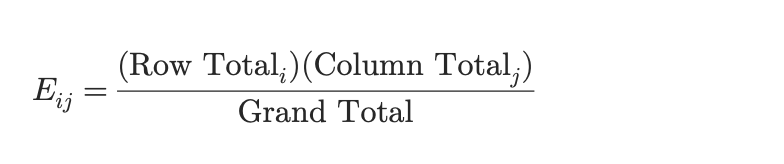

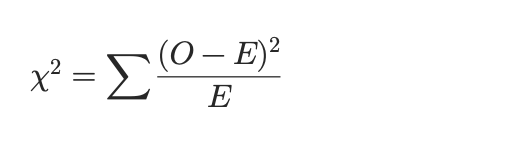

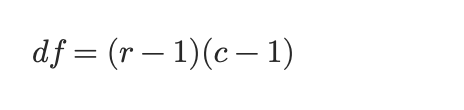

In [ ]:

# Chi-Square Test of Independence

import numpy as np
from scipy import stats

# -----------------------------
# Step 1: Observed Contingency Table
# -----------------------------
observed = np.array([
    [30, 20],   # Male
    [25, 25]    # Female
])

# -----------------------------
# Step 2: Row Totals, Column Totals, Grand Total
# -----------------------------
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
grand_total = observed.sum()

# -----------------------------
# Step 3: Expected Frequencies (Manual)
# E = (Row Total × Column Total) / Grand Total
# -----------------------------
expected = np.outer(row_totals, col_totals) / grand_total

# -----------------------------
# Step 4: Chi-Square Statistic (Manual)
# χ² = Σ (O - E)^2 / E
# -----------------------------
chi_square_stat = ((observed - expected) ** 2 / expected).sum()

# -----------------------------
# Step 5: Degrees of Freedom
# df = (r - 1)(c - 1)
# -----------------------------
r, c = observed.shape
df = (r - 1) * (c - 1)

# -----------------------------
# Step 6: Find p-value and critical_value
# -----------------------------
alpha = 0.05

p_value = 1 - stats.chi2.cdf(chi_square_stat, df)
critical_value = stats.chi2.ppf(1 - alpha, df)

# -----------------------------
# Step 7: Decision
# -----------------------------

# if p_value < alpha:
#     decision = "Reject H0 (Variables are related)"
# else:
#     decision = "Fail to Reject H0 (Variables are independent)"

if chi_square_stat > critical_value:
    decision = "Reject H0 (Variables are related)"
else:
    decision = "Fail to Reject H0 (Variables are independent)"

# -----------------------------
# Final Output
# -----------------------------
print("Observed Table:\n", observed)
print("\nExpected Table:\n", expected)
print("\nChi-Square Statistic:", chi_square_stat)
print("Degrees of Freedom:", df)
print("p-value:", p_value)
print("Critical Value:", critical_value)
print("Decision:", decision)

Observed Table:
 [[30 20]
 [25 25]]

Expected Table:
 [[27.5 22.5]
 [27.5 22.5]]

Chi-Square Statistic: 1.0101010101010102
Degrees of Freedom: 1
p-value: 0.31487864133641974
Critical Value: 3.841458820694124
Decision: Fail to Reject H0 (Variables are independent)



## 📝 Practice Questions
1.	What does the Central Limit Theorem state in simple words?
2.	Why is CLT important in inferential statistics?
3.	What happens to the sampling distribution when sample size increases?
4.	Why is sample size ≥ 30 often recommended?

5.	When do we use the Chi-Square Test?
6.	Difference between:
- Goodness of Fit test
- Test of Independence
7.	How are degrees of freedom calculated in:
- Goodness of Fit
- Independence test?
8.	Why is Chi-Square always right-tailed?


## 📌 Mini Assignment

**Question 1: Central Limit Theorem (CLT)**

📘 Scenario

An e-commerce company has highly skewed order values.

You are given:
	•	Population mean = ₹2000
	•	Population standard deviation = ₹800

You take a sample of size n = 40.

⸻

📝 Tasks

1.	State the Central Limit Theorem.
2.	Calculate:
- Standard Error
3.	Find probability that sample mean exceeds ₹2200.
4.	Interpret the result in business context.
5.	Simulate sampling distribution using Python.
6.	Plot histogram of sample means.
7.	Explain why distribution looks normal even if population is skewed.

**Question 2: Chi-Square Test (Goodness of Fit)**

📘 Scenario

A telecom company claims that customer complaints are distributed as:
| Category | Expected % |
|----------|------------|
| Network  |     50%    |
| Billing  |     30%    |
| Service  |     20%    |

From 300 complaints, observed counts are:
| Category |  Observed  |
|----------|------------|
| Network  |     120    |
| Billing  |     110    |
| Service  |      70    |

Test the claim at α = 0.05.

📝 Tasks

1.	State H₀ and H₁.
2.	Calculate expected frequencies.
3.	Compute Chi-Square statistic manually.
4.	Find degrees of freedom.
5.	Compute p-value.
6.	Find critical Chi-Square value.
7.	Make decision using:
- Method-1 (p-value comparison)
- Method-2 (critical value comparison)
8.	Interpret result in plain English.

**Question 3: Chi-Square Test of Independence**

📘 Scenario

A survey checks if Device Type affects Subscription Plan.

|            |  Basic  |  Premium  |
|------------|---------|-----------|
|  Android   |    80   |     40    |
|     iOS    |    60   |     70    |

Test whether subscription plan depends on device type at α = 0.05.

📝 Tasks

1.	State H₀ and H₁.
2.	Compute expected frequencies.
3.	Calculate Chi-Square statistic.
4.	Compute degrees of freedom.
5.	Find p-value.
6.	Compute critical value.
7.	Apply BOTH decision methods.
8.	Interpret association in business language.
